In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

TypeError: 'NoneType' object is not subscriptable

In [ ]:
!kaggle datasets download -d debanshupal/fake-profile-detection-dataset
!unzip -q '*.zip' -d dataset
!ls -la dataset

Dataset URL: https://www.kaggle.com/datasets/debanshupal/fake-profile-detection-dataset
License(s): unknown
100% 1.06M/1.06M [00:00<00:00, 147MB/s]

total 4252
drwxr-xr-x 2 root root    4096 Apr 14 05:20 .
drwxr-xr-x 1 root root    4096 Apr 14 05:20 ..
-rw-r--r-- 1 root root 1885585 Dec 29  2024 fusers.csv
-rw-r--r-- 1 root root 2454187 Dec 29  2024 users.csv


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
!unzip fake-profile-detection-dataset.zip -d dataset
!ls dataset

Archive:  fake-profile-detection-dataset.zip
replace dataset/fusers.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: dataset/fusers.csv      
replace dataset/users.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: dataset/users.csv       
fusers.csv  users.csv


In [ ]:
import pandas as pd
# Load both CSVs
df_fusers = pd.read_csv("dataset/fusers.csv")
df_users = pd.read_csv("dataset/users.csv")

print("FUSERS:")
print(df_fusers.head(),"\n")
print(df_fusers.info(),"\n")

print("USERS:")
print(df_users.head(),"\n")
print(df_users.info(),"\n")



FUSERS:
          id                  name   screen_name  statuses_count  \
0   80479674               YI YUAN     yi_twitts              29   
1   82487179        Marcos Perez C   marcos_peca            1408   
2  105830531         curti lorenzo  curtilorenzo              39   
3  114488344  ruben dario toscano     gatito2710              59   
4  123222267          Malek Khalaf   MalekKhalaf             987   

   followers_count  friends_count  favourites_count  listed_count  \
0               19            255                 1             0   
1              208            866               138             0   
2               59            962                 8             0   
3                7             49                 4             0   
4               60            521                61             1   

                       created_at                                     url  \
0  Wed Oct 07 03:19:21 +0000 2009                  http://www.jycondo.com   
1  Wed Oct 14 

In [ ]:
df_fusers['label'] = 0 #Fake
df_users['label'] = 1 #Real

df = pd.concat([df_fusers, df_users], ignore_index=True)

print(df['label'].value_counts()) # check balance of classes
df.head()

label
1    3474
0    3351
Name: count, dtype: int64


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,...,notifications,description,contributors_enabled,following,updated,label,timestamp,crawled_at,test_set_1,test_set_2
0,80479674,YI YUAN,yi_twitts,29,19,255,1,0,Wed Oct 07 03:19:21 +0000 2009,http://www.jycondo.com,...,NaN,real estate sales,NaN,NaN,2013-06-12 18:38:35,0,NaN,NaN,NaN,NaN
1,82487179,Marcos Perez C,marcos_peca,1408,208,866,138,0,Wed Oct 14 23:40:17 +0000 2009,NaN,...,NaN,NaN,NaN,NaN,2013-06-12 18:38:35,0,NaN,NaN,NaN,NaN
2,105830531,curti lorenzo,curtilorenzo,39,59,962,8,0,Sun Jan 17 16:46:52 +0000 2010,http://www.valcavargna.com/,...,NaN,le corna del capro scappato dal gregge s'infil...,NaN,NaN,2013-06-12 18:38:35,0,NaN,NaN,NaN,NaN
3,114488344,ruben dario toscano,gatito2710,59,7,49,4,0,Mon Feb 15 15:49:58 +0000 2010,NaN,...,NaN,NaN,NaN,NaN,2013-06-12 18:38:35,0,NaN,NaN,NaN,NaN
4,123222267,Malek Khalaf,MalekKhalaf,987,60,521,61,1,Mon Mar 15 11:38:55 +0000 2010,http://www.facebook.com/Malek.AlBalawi,...,NaN,"MA student at JU, Interested in Juventus,Italy...",NaN,NaN,2013-06-11 17:39:44,0,NaN,NaN,NaN,NaN


In [ ]:
print(df.describe())

                 id  statuses_count  followers_count  friends_count  \
count  6.825000e+03     6825.000000      6825.000000    6825.000000   
mean   8.499737e+08     8667.221685       717.874432     504.022564   
std    7.662248e+08    23473.945131     12301.657025    1159.286294   
min    6.780330e+05        0.000000         0.000000       0.000000   
25%    2.597067e+08       23.000000        12.000000     206.000000   
50%    6.168972e+08      190.000000        33.000000     312.000000   
75%    1.174963e+09     6900.000000       349.000000     555.000000   
max    3.164942e+09   399555.000000    986837.000000   46310.000000   

       favourites_count  listed_count  default_profile  default_profile_image  \
count       6825.000000   6825.000000           4066.0                   19.0   
mean        2378.999121      9.959853              1.0                    1.0   
std         8548.235726    112.952257              0.0                    0.0   
min            0.000000      0.00000

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 43 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  6825 non-null   int64  
 1   name                                6824 non-null   object 
 2   screen_name                         6825 non-null   object 
 3   statuses_count                      6825 non-null   int64  
 4   followers_count                     6825 non-null   int64  
 5   friends_count                       6825 non-null   int64  
 6   favourites_count                    6825 non-null   int64  
 7   listed_count                        6825 non-null   int64  
 8   created_at                          6825 non-null   object 
 9   url                                 1367 non-null   object 
 10  lang                                6825 non-null   object 
 11  time_zone                           2810 no

In [ ]:
print (df.shape)

(6825, 43)


In [ ]:
df['label']. value_counts(normalize=True) * 100

,proportion
label,
1,50.901099
0,49.098901


In [ ]:
df.isnull().sum()

,0
id,0
name,1
screen_name,0
statuses_count,0
followers_count,0
friends_count,0
favourites_count,0
listed_count,0
created_at,0
url,5458


In [ ]:
print(df.duplicated().sum)

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
6820    False
6821    False
6822    False
6823    False
6824    False
Length: 6825, dtype: bool>


In [ ]:
print(df.columns)

Index(['id', 'name', 'screen_name', 'statuses_count', 'followers_count',
       'friends_count', 'favourites_count', 'listed_count', 'created_at',
       'url', 'lang', 'time_zone', 'location', 'default_profile',
       'default_profile_image', 'geo_enabled', 'profile_image_url',
       'profile_banner_url', 'profile_use_background_image',
       'profile_background_image_url_https', 'profile_text_color',
       'profile_image_url_https', 'profile_sidebar_border_color',
       'profile_background_tile', 'profile_sidebar_fill_color',
       'profile_background_image_url', 'profile_background_color',
       'profile_link_color', 'utc_offset', 'is_translator',
       'follow_request_sent', 'protected', 'verified', 'notifications',
       'description', 'contributors_enabled', 'following', 'updated', 'label',
       'timestamp', 'crawled_at', 'test_set_1', 'test_set_2'],
      dtype='object')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(df['label'].value_counts())

label
1    3474
0    3351
Name: count, dtype: int64


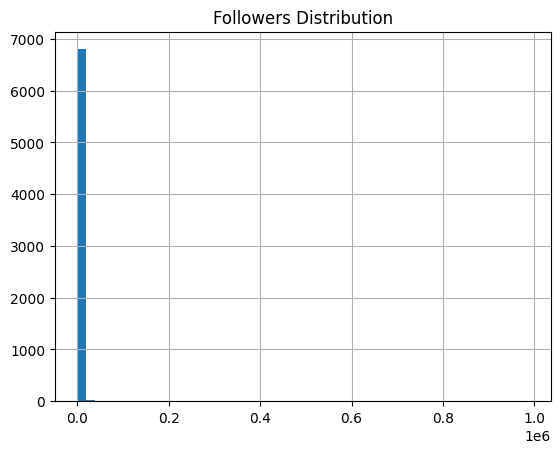

In [ ]:
df['followers_count'].hist(bins=50)
plt.title("Followers Distribution")
plt.show()

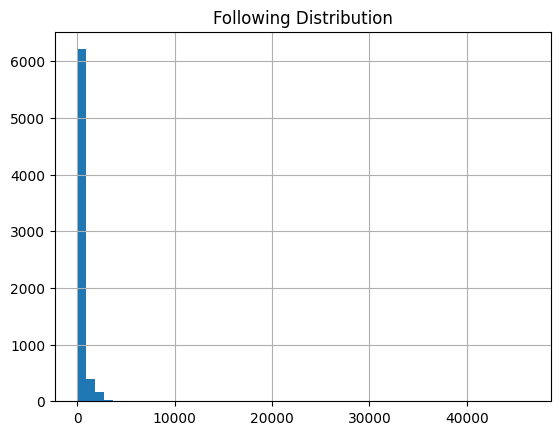

In [ ]:
df['friends_count'].hist(bins=50)
plt.title("Following Distribution")
plt.show()

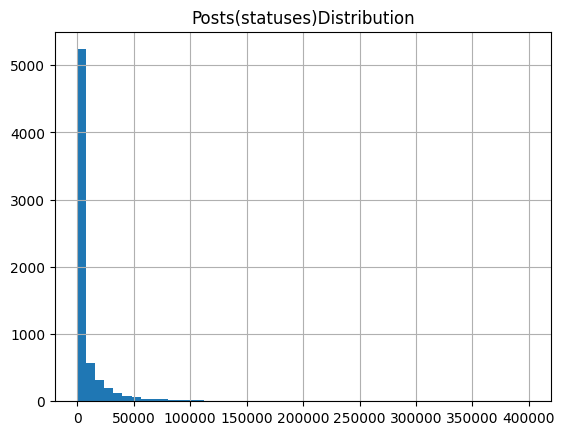

In [ ]:
df['statuses_count'].hist(bins=50)
plt.title("Posts(statuses)Distribution")
plt.show()

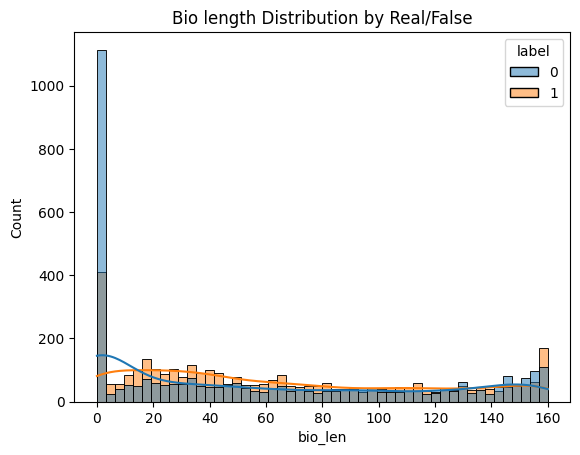

In [ ]:
df['bio_len']=df['description'].fillna('').apply(len)
sns.histplot(data=df,x='bio_len',hue= 'label',bins=50,kde=True)
plt.title("Bio length Distribution by Real/False")
plt.show()

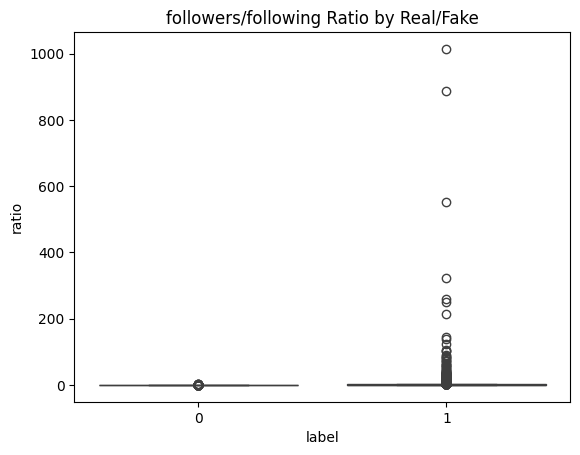

In [ ]:
df['ratio']=df['followers_count']/(df['friends_count']+1)
sns.boxplot(
    x='label', y= 'ratio', data=df)
plt.title("followers/following Ratio by Real/Fake")
plt.show()

In [ ]:
import pandas as pd
df['created_at']=pd.to_datetime(df['created_at'],errors='coerce', utc=True)
today=pd.Timestamp.now(tz='UTC')
df['account_age_days']=(today - df['created_at']).dt.days
print(df[['created_at','account_age_days']].head())


/tmp/ipykernel_3831/232025788.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at']=pd.to_datetime(df['created_at'],errors='coerce', utc=True)


                 created_at  account_age_days
0 2009-10-07 03:19:21+00:00              6033
1 2009-10-14 23:40:17+00:00              6025
2 2010-01-17 16:46:52+00:00              5930
3 2010-02-15 15:49:58+00:00              5901
4 2010-03-15 11:38:55+00:00              5873


# ***THE CODE IS RUN SUCCESSFULLY WITHOUT ANY ERROR'S***

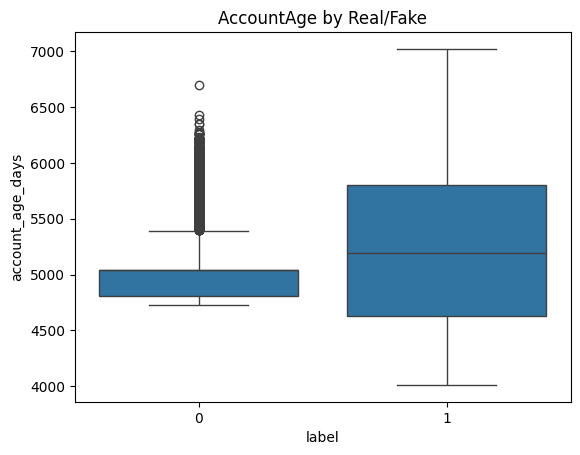

In [ ]:
sns.boxplot(x='label', y='account_age_days', data=df)
plt.title("AccountAge by Real/Fake")
plt.show()

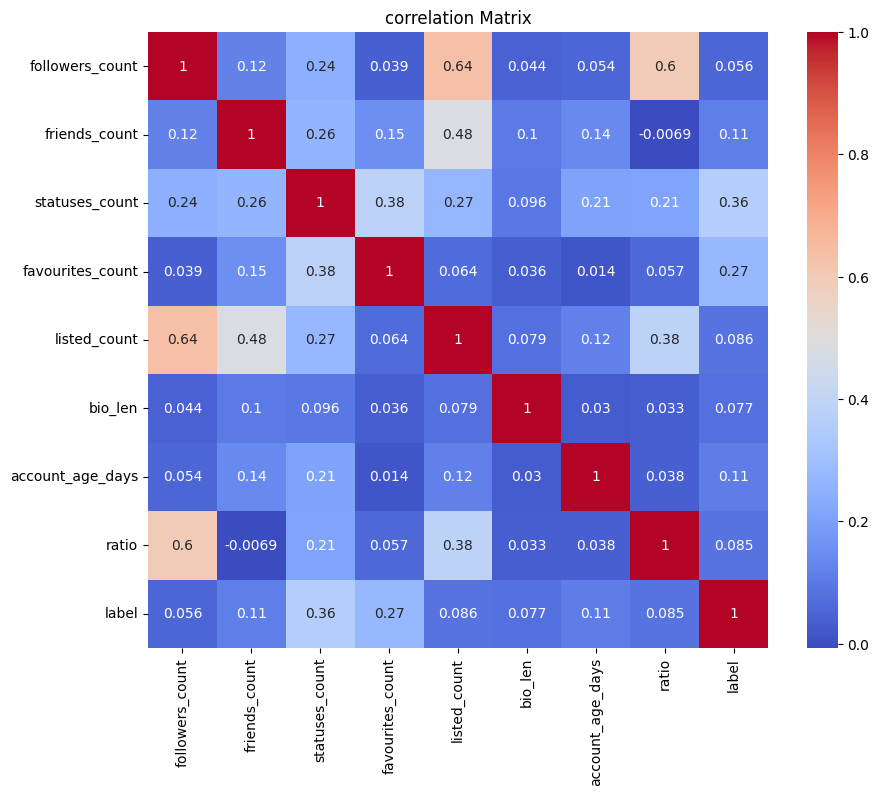

In [ ]:
corr = df[['followers_count','friends_count','statuses_count',
           'favourites_count','listed_count','bio_len',
           'account_age_days'
           ,'ratio','label']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

In [ ]:
features =[
    'followers_count',
    'friends_count',
    'statuses_count',
    'favourites_count',
    'listed_count',
    'bio_len',
    'account_age_days',
    'ratio'
]
x = df[features]
y = df['label']


In [ ]:
print(x.isnull().sum())

followers_count     0
friends_count       0
statuses_count      0
favourites_count    0
listed_count        0
bio_len             0
account_age_days    0
ratio               0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


In [ ]:
import numpy as np
def detect_outliers_iqr(data,col):
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1 - 1.5* IQR
  upper = Q3 + 1.5* IQR
  return data[(data[col] < lower)|(data[col] > upper)]

#Example: Check for outliers in followers_count
outliers_followers = detect_outliers_iqr(df,'followers_count')
print("outliers in followers_count:",outliers_followers.shape[0])

outliers in followers_count: 821


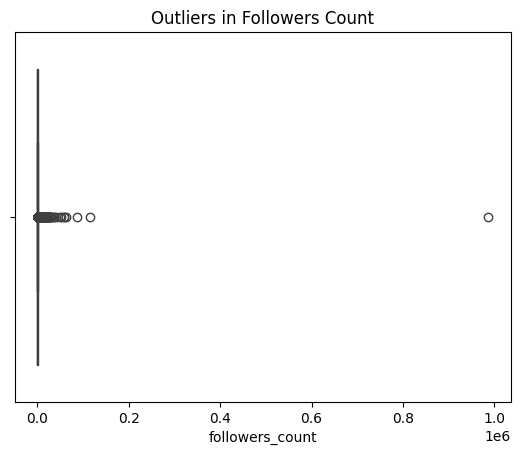

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['followers_count'])
plt.title("Outliers in Followers Count")
plt.show()

In [ ]:
import numpy as np
df['followers_count_log'] = np.log1p(df['followers_count'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Features and Target
features =[
    'followers_count',
    'friends_count',
    'statuses_count',
    'favourites_count',
    'listed_count',
    'bio_len',
    'account_age_days',
    'ratio'
]



In [ ]:
x= df[features]
y= df['label']

# 1. Train-test slipt
X_train, X_test, Y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

#2. scalling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (5460, 8)
Test shape: (1365, 8)


In [ ]:
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled test set shape:", X_test.shape)

Scaled training set shape: (5460, 8)
Scaled test set shape: (1365, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.85      1.00      0.91       670
           1       0.99      0.83      0.90       695

    accuracy                           0.91      1365
   macro avg       0.92      0.91      0.91      1365
weighted avg       0.92      0.91      0.91      1365



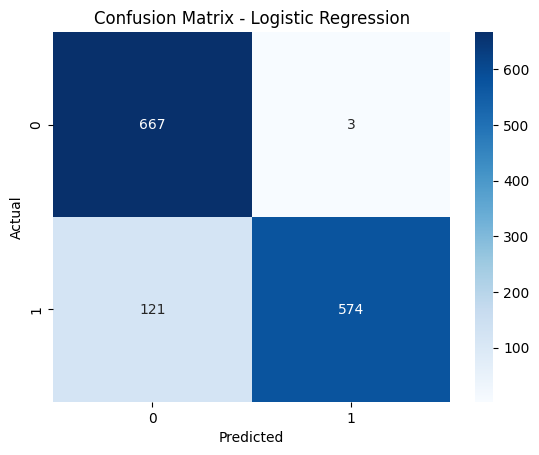


Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       670
           1       0.99      0.99      0.99       695

    accuracy                           0.99      1365
   macro avg       0.99      0.99      0.99      1365
weighted avg       0.99      0.99      0.99      1365



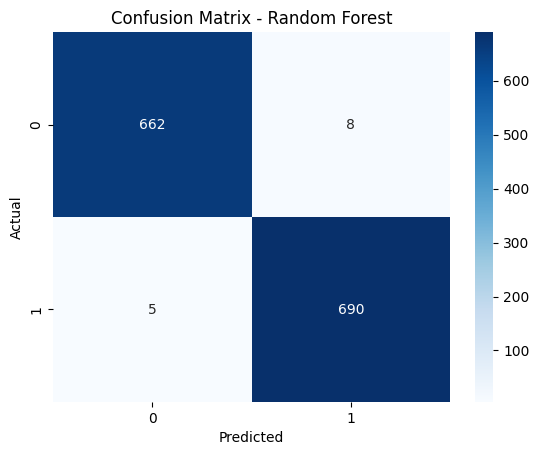

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:10:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       670
           1       0.99      0.99      0.99       695

    accuracy                           0.99      1365
   macro avg       0.99      0.99      0.99      1365
weighted avg       0.99      0.99      0.99      1365



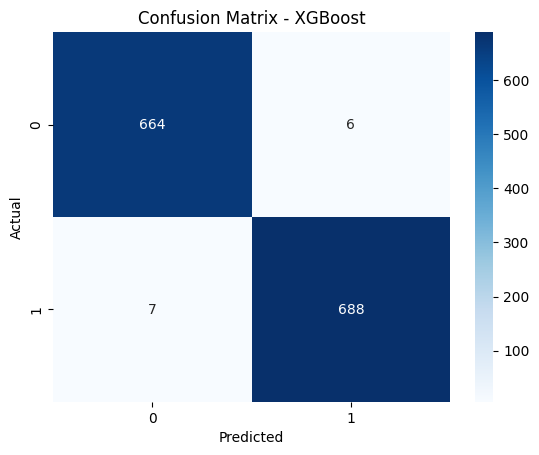


Model comparison:
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.909158   0.994801  0.825899  0.902516
Random Forest        0.990476   0.988539  0.992806  0.990668
XGBoost              0.990476   0.991354  0.989928  0.990641


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False)
}

results = {}

for name, model in models.items():
  model.fit(X_train_scaled, Y_train)
  y_pred=model.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  results[name] = [acc,prec,rec,f1]

  print(f"\n{name} Results:")
  print(classification_report(y_test, y_pred))

  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
  plt.title(f"Confusion Matrix - {name}")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()



results_df=pd.DataFrame(results, index=["Accuracy","Precision","Recall","F1"])
print("\nModel comparison:")
print(results_df.T)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve,auc
import matplotlib.pyplot as plt

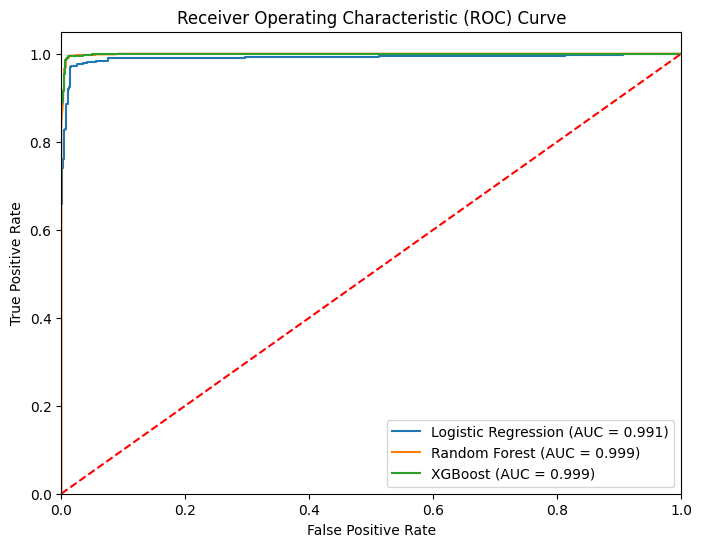

In [ ]:
plt.figure(figsize=(8,6))
for name, model in models.items():
  # Predict probabilities for the positive class (label=1)
  if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
  else:
    y_pred_proba = model.decision_function(X_test_scaled)

  # ROC curve
  fpr, tpr,_ = roc_curve(y_test, y_pred_proba)
  roc_auc = auc(fpr, tpr)

  plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

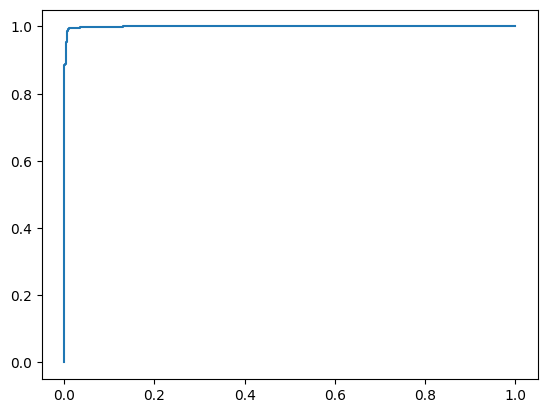

In [ ]:
# Predict probabilities for the positive class (label=1)

if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

else:
    y_pred_proba = model.decision_function(X_test_scaled)

# ROC curve
fpr, tpr,_ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

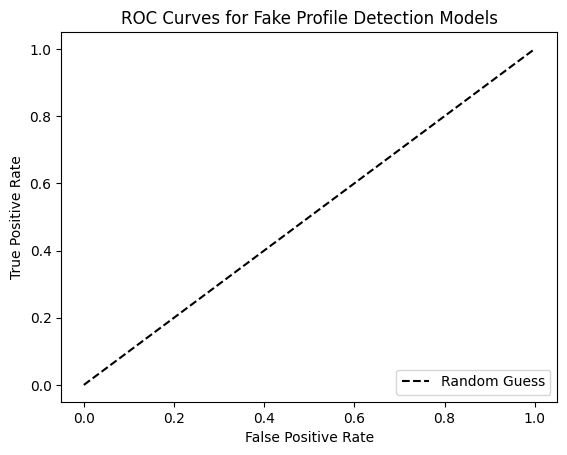

In [ ]:

# Plot baseline (moved outside the loop)
plt.plot([0,1],[0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Fake Profile Detection Models")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import joblib

# Save the best model (Random Forest in this case)
best_model = models["Random Forest"]
joblib.dump(best_model, "fake_profile_model.pkl")


['fake_profile_model.pkl']

In [ ]:
from google.colab import files
files.download("fake_profile_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>